# Factory IO 모드버스 연결제어
### 데이터센터 냉각수제어
#### modbus_water01 연결

In [ ]:
from pymodbus.client import ModbusTcpClient
import time as tt
import threading

client = ModbusTcpClient('210.119.14.74', port=502)
client.connect()

물의 수위: 0% / 배수량: 0L/s

![스크린샷 2026-07-14 105417.png](<attachment:스크린샷 2026-07-14 105417.png>)
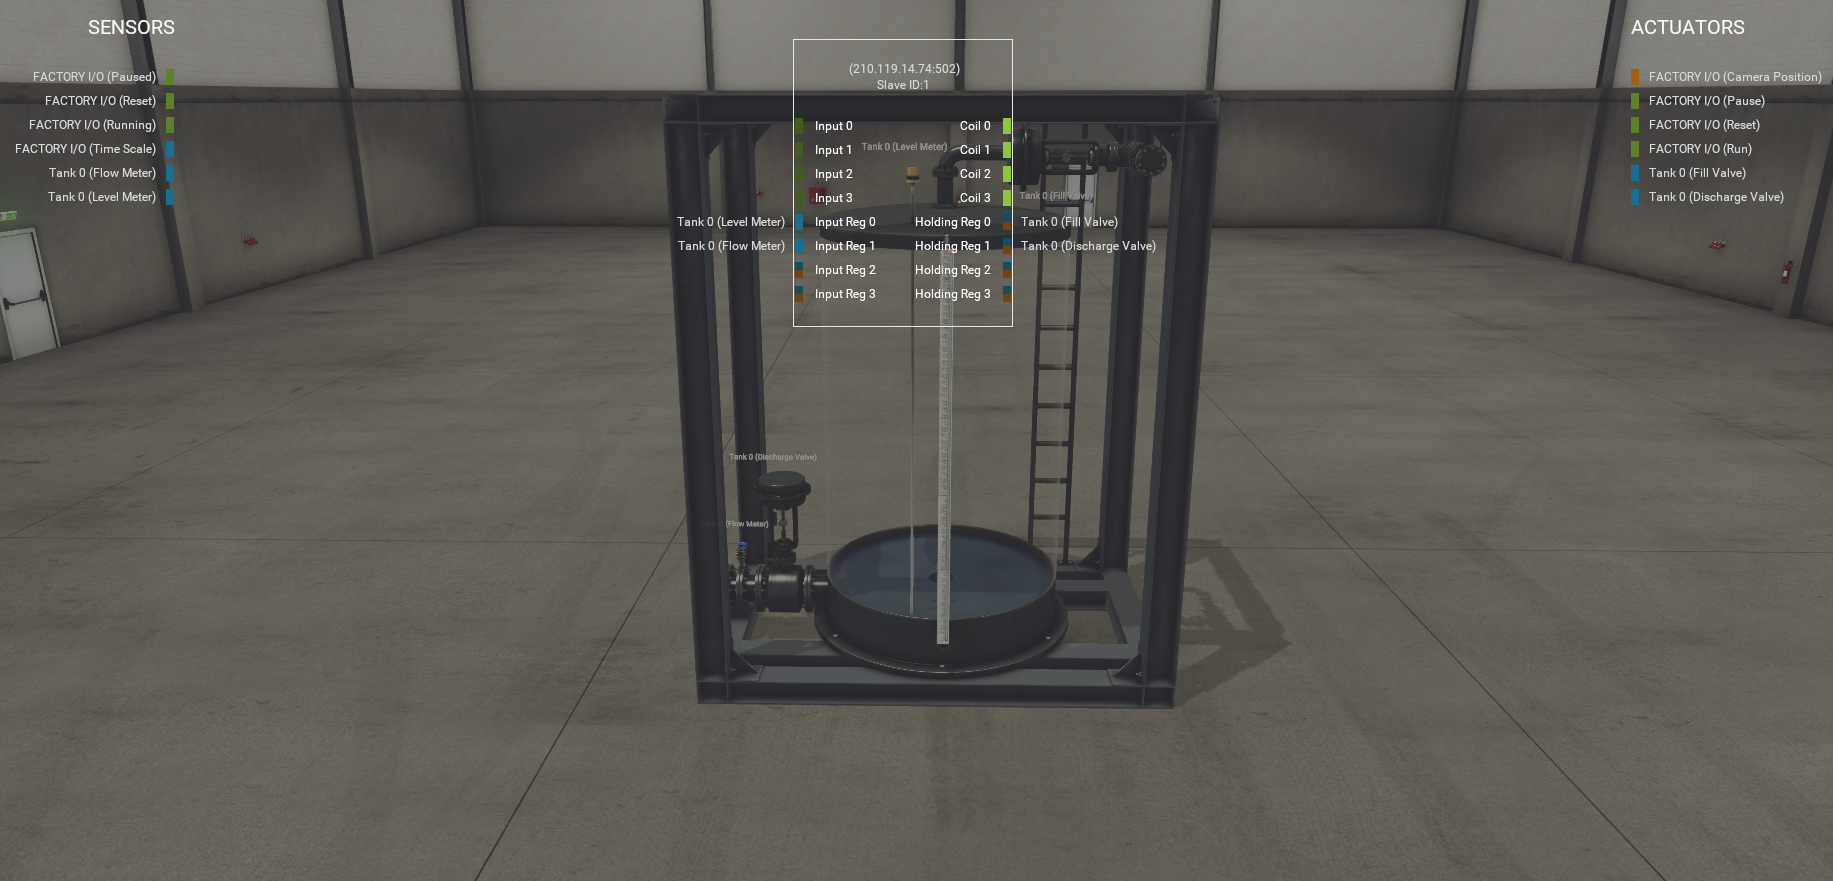

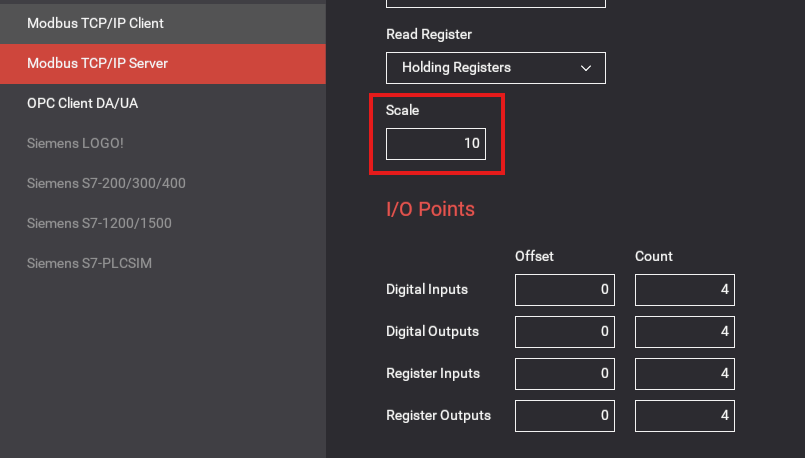

### 아날로그 출력 제어

In [ ]:
# Fill Valve 제어
Fvalve = 0
client.write_register(0, Fvalve) # 40001에 어떠한 값을 보내기

# Fvalve = 0 → 밸브 닫힘, 물 안 참
# Fvalve = 50 → 밸브 절반 정도 열림, 물이 중간 속도로 참
# Fvalve = 100 → 밸브 완전히 열림, 물이 빠르게 참

물의 수위: 0% / 배수량: 0L/s

물의 수위: 0% / 배수량: 0L/s

In [107]:
# Discharge Valve 제어
Dvalve = 10
client.write_register(1,Dvalve) # 40002에 어떠한 값을 보내기

# Dvalve = 0    → 배수 밸브 닫힘, 물 안 빠짐
# Dvalve = 55   → 배수 밸브 조금 열림, 물이 천천히 빠짐
# Dvalve = 100  → 배수 밸브 완전히 열림, 물이 빠르게 빠짐

물의 수위: 60% / 배수량: 27L/s

물의 수위: 60% / 배수량: 27L/s

물의 수위: 68% / 배수량: 8L/ss

In [ ]:
# registers로 여러주소 동시제어
# client.write_registers(0, [Fvalve,Dvalve])
# 초기화 시키기
client.write_registers(0, [0,0])

In [104]:
hr = client.read_holding_registers(0,count=4) # 40001 ~ 40004까지 읽어오기
hr.registers

물의 수위: 66% / 배수량: 28L/s

[50, 35, 100, 0]

물의 수위: 66% / 배수량: 28L/s

물의 수위: 66% / 배수량: 28L/s

In [ ]:
scan_run = True # 반복 실행
def meter_scan():
    while scan_run: # scan_run = True일 때 while문 반복
        water_Meter = client.read_input_registers(0,count=4).registers # Modbus - Input register 0~3개 읽음 # 주소 - Input Reg 0 → 30001, Input Reg 1 → 30002 ...
        print(f"\r물의 수위: {water_Meter[0]}% / 배수량: {water_Meter[1]}L/s", end="") 
        
        # 밸브 제어
        if (70 - water_Meter[0]) < 1: # 목표 수위 70%에 도달시
            client.write_register(0, 0) # 주입 밸브를 닫음
        if (70 - water_Meter[0]) < 5: # 목표 수위까지 5% 미만
            client.write_register(0, 5) # 5만큼의 밸브를 엶
        elif (70 - water_Meter[0]) <= 10:
            client.write_register(0, 20)
        elif (70 - water_Meter[0]) <= 20:
            client.write_register(0, 50)
        elif (70 - water_Meter[0]) <= 50:
            client.write_register(0, 80)
        elif (70 - water_Meter[0]) <= 100: # 목표 수위까지 100% 이하
            client.write_register(0, 100) # 100만큼 밸브를 엶
            
        tt.sleep(0.1)

scan = threading.Thread(target=meter_scan, daemon=True)
print(" 모니터링 시작")
scan.start()

물의 수위: 68% / 배수량: 8L/s 모니터링 시작
물의 수위: 68% / 배수량: 8L/s

물의 수위: 0% / 배수량: 8L/ss

구조
- 배수는 일정하게 빠짐
- 주입량은 수위에 따라 자동 조절됨
- 결과적으로 수위가 70% 근처로 유지됨

In [ ]:
scan_run = False #scan_run = False일 때 while문 멈춤

#### 원격 접속

In [ ]:
from pymodbus.client import ModbusTcpClient
import time as tt
import threading

client = ModbusTcpClient('210.119.14.56', port=502)
if client.connect():
    print("Factory I/O 서버에 접속완료.")

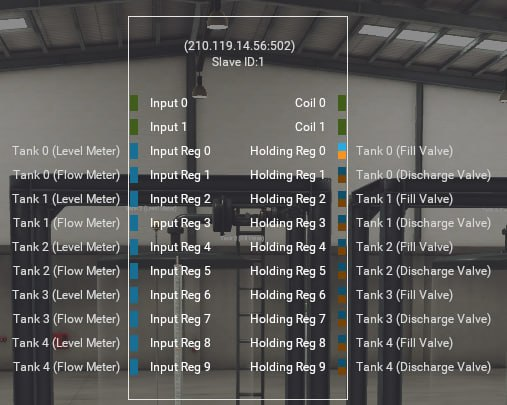

In [ ]:
# Fill Valve 제어
Fvalve = 40
client.write_register(0, Fvalve) # 40001에 어떠한 값을 보내기

In [ ]:
# Discharge Valve 제어
Dvalve = 35
client.write_register(1,Dvalve) # 40002에 어떠한 값을 보내기

In [ ]:
# Tank1 - 물의 수위 77%로 맞추기
scan_run = True # 반복 실행
def meter_scan():
    while scan_run: # scan_run = True일 때 while문 반복
        water_Meter = client.read_input_registers(0,count=10).registers # Modbus - Input register 0~9개 읽음 # 주소 - Input Reg 0 → 30001, Input Reg 1 → 30002 ...
        print(f"\r물의 수위: {water_Meter[2]}% / 배수량: {water_Meter[3]}L/s", end="")
        
        if (77 - water_Meter[2]) < 1: 
            client.write_register(2, 0)
        if (77 - water_Meter[2]) < 5:
            client.write_register(2, 5)
        elif (77 - water_Meter[2]) <= 10:
            client.write_register(2, 20)
        elif (77 - water_Meter[2]) <= 20:
            client.write_register(2, 50)
        elif (77 - water_Meter[2]) <= 50:
            client.write_register(2, 80)
        elif (77 - water_Meter[2]) <= 100:
            client.write_register(2, 100)
            
        tt.sleep(0.1)

scan = threading.Thread(target=meter_scan, daemon=True)
print(" 모니터링 시작")
scan.start()